# KANVAS on a Real GPU Cluster: Which Tasks Fail, and Why?

In [`01_toy_demo`](01_toy_demo.ipynb) we checked, on synthetic data with a known answer, that **KANVAS** recovers each feature's true effect. KANVAS is an additive model in which every input feature gets its own learned curve $\varphi_i$:

$$\text{risk} = \sigma\Big(\sum_i \varphi_i(x_i) + b\Big)$$

This notebook points the same, unmodified model at production infrastructure data: the **Alibaba PAI GPU cluster trace** (`cluster-trace-gpu-v2020`). It covers about 1.26 million tasks over a ~69-day window on a fleet of 1,897 machines.

The question is the one an SRE asks after an incident review: *given what a task asked for and the state of the node it landed on, how likely is it to fail, and which factor pushes that risk up?*

Because no feature can interact with another inside the model, the answer comes as ten curves. Each one can be read on its own, with no SHAP values and no surrogate model.

**Roadmap**
1. The raw trace, the label, and two traps it contains
2. Build the dataset: five raw tables become ten features, with a row count at every step
3. Look at the feature distributions
4. Split the data, see why raw trace units break training, and scale per feature
5. Train KAAM with the same loop as the toy demo
6. Evaluate: accuracy, AUC and the confusion matrix
7. Read the ten $\varphi_i$ curves

## 1. The raw trace: five tables, one join path

| Table | One row per | What KANVAS takes from it |
|---|---|---|
| `pai_task_table` | task | the **label** (`status`) and the resource request: `plan_cpu`, `plan_mem`, `plan_gpu`, `inst_num` |
| `pai_instance_table` | task instance (a worker process) | the task's **first instance**: which `machine` it ran on and when it started |
| `pai_machine_metric` | worker | machine-level utilization (CPU, GPU, load, network), averaged over that worker's lifetime |
| `pai_machine_spec` | machine | hardware: `cap_gpu` |
| `pai_job_table` | job | only inspected; labels come from the task table |

`pai_task_table` has no worker or machine column, so `pai_instance_table` is the bridge between *what a task requested* and *where it ran*:

```
pai_task_table --(job_name, task_name)--> pai_instance_table (first instance)
    --(machine + 1 h lookback before instance start)--> pai_machine_metric
    --(machine)--> pai_machine_spec
```

The timestamps are **relative seconds**, not Unix epoch times. Read as epoch times they would fall in January–March 1970. The trace's time origin is anonymized, but every table uses the same clock, which is all a temporal join needs.

### The label

`pai_task_table.status` takes exactly four values: `Terminated` (finished normally), `Failed`, `Running` and `Waiting`. We set **label = 1 for `Failed`** and **0 for `Terminated`**, and **drop `Running` and `Waiting`**. Those tasks had no outcome yet when the trace was cut, and counting them as successes would quietly corrupt a failure target. That drop removes 119,215 rows (9.45%) and leaves a 22.49% failure rate.

### Two traps in this trace, and how the pipeline avoids them

**Trap 1: node telemetry only survives for healthy workers.** `pai_machine_metric` holds one row per worker. Across the full trace, 42% of `Terminated` instances have such a row, but only **0.09% of `Failed`** ones do, and 99% of failed tasks' first instances never record an `end_time`. The intuitive join, "average the metrics over the task's own run window", therefore keeps almost no failures. We tried it on this same sample: **2 failures in 996 tasks**.

So the pipeline reads the assigned node's state from **other jobs' workers on the same machine that finished in the hour before the task started**. That signal exists for failed and successful tasks alike, and it never uses information from after the task began, so nothing about the outcome can leak in.

**Trap 2: features that look informative but aren't.**
- *"Requested vs. assigned GPU type."* The task table's `gpu_type` is the type of the machine the task was *placed* on: it agreed with the machine's type for 100% of the 4,294 sampled tasks where both were known. As a feature it would be a constant.
- *IO wait.* `machine_cpu_iowait` is missing for 80% of rows on MISC-GPU nodes but only 6% on T4 nodes. Requiring it would silently drop most MISC-node tasks and skew the failure rate.

Both were replaced by other machine-level readings from the same table: `avg_net_receive` and `avg_cpu_kernel`.

### The ten features

Each feature traces back to exactly one named raw column, so each $\varphi_i$ curve answers a single question.

| # | Feature | Raw source | What it tells an SRE |
|---|---|---|---|
| 1 | `plan_cpu` | `pai_task_table.plan_cpu` | CPU requested (100 = 1 core) |
| 2 | `plan_mem` | `pai_task_table.plan_mem` | memory requested (GB) |
| 3 | `plan_gpu` | `pai_task_table.plan_gpu` | GPU requested (100 = 1 GPU; 25 or 50 means a shared GPU) |
| 4 | `inst_num` | `pai_task_table.inst_num` | number of instances; more than 1 means a distributed task |
| 5 | `avg_cpu_usr` | `pai_machine_metric.machine_cpu_usr` | user-space CPU busy % on the node in the hour before the task started |
| 6 | `avg_gpu_util` | `pai_machine_metric.machine_gpu` | GPU utilization summed over the node's GPUs (100 = one fully busy GPU) |
| 7 | `avg_cpu_kernel` | `pai_machine_metric.machine_cpu_kernel` | kernel-mode CPU %: syscall, interrupt and IO handling pressure |
| 8 | `avg_load_1` | `pai_machine_metric.machine_load_1` | 1-minute load average: run-queue contention |
| 9 | `cap_gpu` | `pai_machine_spec.cap_gpu` | GPUs installed on the node (a hardware class, not telemetry) |
| 10 | `avg_net_receive` | `pai_machine_metric.machine_net_receive` | network receive rate on the node (trace units): data loading and parameter traffic |

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler
from matplotlib.ticker import FuncFormatter, MaxNLocator
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

from kanvas.data import FEATURE_NAMES, build_kanvas_dataset, scale_features
from kanvas.model import KAAM
from kanvas.utils import set_seed

%matplotlib inline

# Chart style: light surface, recessive hairline grid, text in ink tones, marks in a validated CVD-safe pair.
TERMINATED, FAILED = "#2a78d6", "#eb6834"
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": "#c3c2b7", "ytick.color": "#c3c2b7", "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.prop_cycle": cycler(color=[TERMINATED, FAILED]), "lines.linewidth": 1.5,
    "legend.frameon": False, "font.size": 10,
})

FEATURE_UNITS = {
    "plan_cpu": "CPU requested (100 = 1 core)",
    "plan_mem": "memory requested (GB)",
    "plan_gpu": "GPU requested (100 = 1 GPU)",
    "inst_num": "instances requested",
    "avg_cpu_usr": "node user CPU (%)",
    "avg_gpu_util": "node GPU util, summed over GPUs (%)",
    "avg_cpu_kernel": "node kernel CPU (%)",
    "avg_load_1": "node 1-min load average",
    "cap_gpu": "GPUs installed on node",
    "avg_net_receive": "node network receive (trace units)",
}


def compact(value):
    # Tick label with M/G suffixes so network rates stay readable.
    for divisor, suffix in ((1e9, "G"), (1e6, "M")):
        if abs(value) >= divisor:
            return f"{value / divisor:g}{suffix}"
    return f"{value:,.4g}"

## 2. Build the dataset

`build_kanvas_dataset()` runs all seven steps and prints a survival report as it goes: how many tasks remain after each step, and exactly why the others were dropped.

It takes about a minute. The 2 GB instance table and the 0.4 GB machine-metric table are **streamed in 1M-row chunks and filtered on the fly**, never loaded whole. The telemetry join then groups machine metrics by machine once, sorts them by end time, and does two binary searches per task instead of scanning the table.

In [2]:
X, y, feature_ranges = build_kanvas_dataset("../data/raw", sample_n_tasks=5000)

[Step 1] pai_task_table: 1,261,050 rows
  drop status='Running': 115,501 rows (unresolved outcome, not a failure/success label)
  drop status='Waiting': 3,714 rows (unresolved outcome, not a failure/success label)
  dropped 119,215 of 1,261,050 rows (9.45%); 1,141,835 labeled rows remain


  full labeled set: 256,762 Failed / 885,073 Terminated -> failure rate 22.49%


  stratified sample: 5,000 tasks, failure rate 22.48% (full labeled set 22.49%)



[Step 2] pai_instance_table streamed: 7,522,002 rows scanned in chunks of 1,000,000
  26,971 instance rows belong to the 5,000 sampled tasks; 1,175 tasks have >1 instance (kept only the earliest-starting one)
  dropped 0 sampled tasks with zero matching instances; 5,000 remain (failure rate 22.48%)



[Step 3] pai_machine_metric streamed: 2,009,423 rows scanned; 1,797,277 rows are on the 1,224 assigned machines
  telemetry window: other jobs' workers on the assigned machine that ended in the 1h before the task's first instance started
  leakage guard: excluded 0 in-window rows that belong to the task's own job
  drop 1,350 tasks: no other job's worker ended on the machine in the lookback window
  drop 186 tasks: assigned machine has no machine_metric rows
  dropped 1,536 tasks with zero machine_metric rows in the window; 3,464 remain (failure rate 26.33%)
  machine_metric rows averaged per task: median 5, 90th pct 13, max 170

[Step 4] pai_machine_spec: 1,897 machines
  dropped 0 tasks whose machine is missing from pai_machine_spec; 3,464 remain (failure rate 26.33%)

[Step 5] engineered 10 features for 3,464 tasks: plan_cpu, plan_mem, plan_gpu, inst_num, avg_cpu_usr, avg_gpu_util, avg_cpu_kernel, avg_load_1, cap_gpu, avg_net_receive

[Step 6] NaN audit over the 10 features + label

**Reading the funnel.** Of the 5,000 sampled tasks, every one matched an instance, and 3,464 had at least one other-job worker finish on their node in the hour before they started. Another 1,154 were dropped for a missing value:
- 171 were CPU-only tasks with no GPU request (`plan_gpu` is NaN), so they fall outside this model's scope.
- The rest had individual telemetry gaps.

That leaves **2,310 tasks, 646 of them failed (27.97%)**.

The failure rate *rises* through the funnel, from 22.5% in the trace to 28% here, because the tasks dropped at each step fail less often than those kept. That is a scope statement, not a bug. This model describes **GPU tasks placed on nodes with recent activity**, and its probabilities are calibrated to a 28% base rate, not the trace-wide 22%.

Two more things to notice:
- Clipping at the 1st/99th percentile touched at most about 2% of any feature's values. It trims sensor spikes, such as P100 nodes reporting over 600% GPU utilization on 2 GPUs, without flattening the distribution.
- The leakage guard (never use telemetry from the task's own job) excluded no rows in this sample. It stays in the pipeline because a retried job's earlier attempt can finish on the same node.

## 3. What the features look like

Each panel is a stacked histogram. The **bar height is the distribution over all tasks**, and the orange segment is how many of them failed. A feature whose orange share changes along the x-axis is one the model has a chance of using.

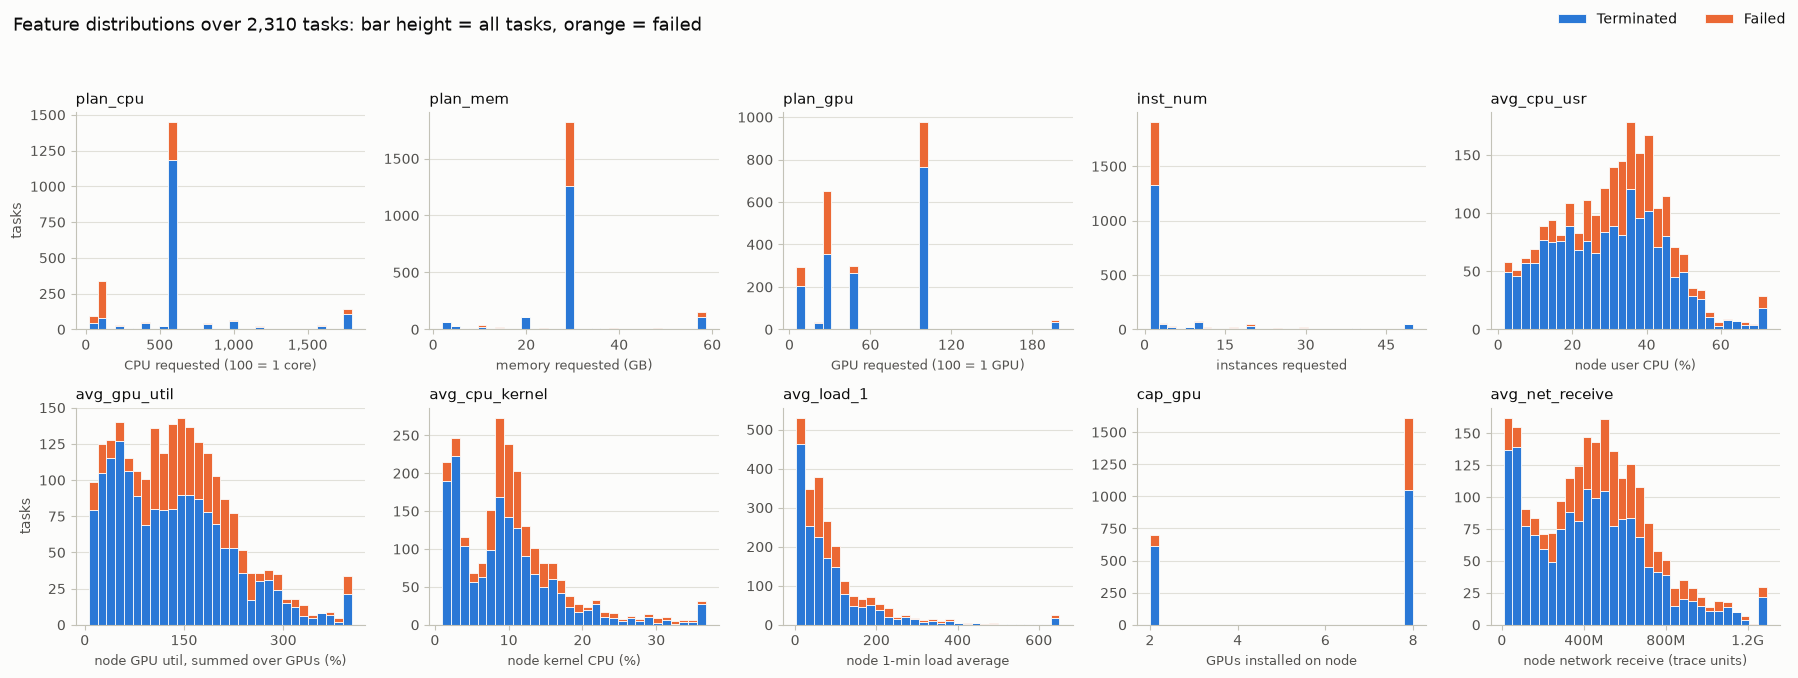

Failure rate by GPUs installed on the node:
         failure_rate  tasks
cap_gpu                     
2.0             0.120    699
8.0             0.349   1611


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6.8))
for ax, name in zip(axes.flat, FEATURE_NAMES):
    bins = np.linspace(*feature_ranges[name], 31)
    ax.hist([X.loc[y == 0, name], X.loc[y == 1, name]], bins=bins, stacked=True,
            color=[TERMINATED, FAILED], edgecolor=SURFACE, linewidth=0.6, label=["Terminated", "Failed"])
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xlabel(FEATURE_UNITS[name], fontsize=9)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: compact(v)))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.grid(axis="y")
    ax.set_axisbelow(True)
for ax in axes[:, 0]:
    ax.set_ylabel("tasks")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)
fig.suptitle(f"Feature distributions over {len(X):,} tasks: bar height = all tasks, orange = failed",
             x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

print("Failure rate by GPUs installed on the node:")
print(y.groupby(X["cap_gpu"]).agg(failure_rate="mean", tasks="size").round(3).to_string())

**What the distributions say.**
- **Requests cluster on a few values.** Most tasks ask for exactly 6 cores (`plan_cpu = 600`) and 29.3 GB, and most are single-instance. The $\varphi$ curves for these features are well supported at those values and interpolate in between.
- **Node state varies widely.** User CPU, GPU utilization, load and network receive each spread across the whole range, so their curves have data behind them almost everywhere.
- **Hardware is bimodal.** Nodes have either 2 GPUs (P100/T4) or 8 (MISC/V100). Failures are visibly concentrated on 8-GPU nodes: about 35% of their tasks fail vs 12% on 2-GPU nodes. Whether that reflects the hardware itself or the larger distributed jobs that get scheduled there is exactly the kind of question the curves can frame but not settle.

## 4. Train/test split, and why raw units break KAAM

We hold out 20% of tasks, stratified on the label so both halves keep the same failure rate.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train_t = torch.tensor(y_train.to_numpy(np.float32))
y_test_t = torch.tensor(y_test.to_numpy(np.float32))

print(f"train: {len(X_train):,} tasks, failure rate {y_train.mean():.2%}")
print(f"test:  {len(X_test):,} tasks, failure rate {y_test.mean():.2%}")

train: 1,848 tasks, failure rate 27.98%
test:  462 tasks, failure rate 27.92%


### Why raw trace units break KAAM

Each `BSplineEdge` computes $\varphi(x) = w_{\text{base}}\cdot\text{SiLU}(x) + B(x)$, the base-plus-spline form from the KAN paper.

- The spline part $B(x)$ sits on a knot grid placed over each feature's own `feature_ranges`, so it adapts to any unit.
- The **base term does not adapt**: $\text{SiLU}(x) \approx x$ for large $x$. `avg_net_receive` is around $4.5\times10^8$ in trace units, so at initialization that one feature contributes a logit in the tens of millions.

The cell below builds KAAM directly on raw units with the real `feature_ranges` and runs the same training loop for 100 epochs, to show what happens.

In [5]:
set_seed(42)
raw_model = KAAM(FEATURE_NAMES, feature_ranges, num_knots=10, spline_order=3)
X_train_raw_t = torch.tensor(X_train.to_numpy(np.float32))

with torch.no_grad():
    init_scale = {name: raw_model.edges[name](X_train_raw_t[:, i]).abs().max().item()
                  for i, name in enumerate(FEATURE_NAMES)}
    raw_preds = raw_model(X_train_raw_t)
print("largest |phi_i| at initialization, raw units:")
for name, value in init_scale.items():
    print(f"  {name:<16s} {value:,.3g}")
print(f"\ntrain predictions saturated to exactly 0 or 1: {((raw_preds == 0) | (raw_preds == 1)).float().mean():.0%}\n")

optimizer = torch.optim.Adam(raw_model.parameters(), lr=0.01)
loss_fn = torch.nn.BCELoss()
for epoch in range(1, 101):
    optimizer.zero_grad()
    loss = loss_fn(raw_model(X_train_raw_t), y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d}/100  train BCE loss: {loss.item():.4f}")

largest |phi_i| at initialization, raw units:
  plan_cpu         178
  plan_mem         3.08
  plan_gpu         38.4
  inst_num         2.9
  avg_cpu_usr      0.622
  avg_gpu_util     1.4
  avg_cpu_kernel   1.65
  avg_load_1       20.6
  cap_gpu          1.54
  avg_net_receive  8.34e+07

train predictions saturated to exactly 0 or 1: 100%



Epoch   50/100  train BCE loss: 72.0238


Epoch  100/100  train BCE loss: 72.0238


Every prediction starts pinned at exactly 0 or 1, and in float32 the sigmoid's gradient there is exactly zero. BCE then sits at a clamped ~72 and **never moves**: this configuration does not converge at all. (A full 1,000-epoch run stays just as flat.)

**The fix is per-feature min-max scaling:**

$$x_i' = \frac{x_i - \min_i}{\max_i - \min_i}$$

Here $(\min_i, \max_i)$ is feature *i*'s own entry in `feature_ranges`, so the transform uses no information from any other feature. Every feature reaches the model on $[0, 1]$, and KAAM gets a unit range for each.

Because the map is a fixed affine transform per feature, each learned curve converts back exactly to raw trace units; we relabel the axes that way in section 7. `model.py` and `bspline.py` are untouched.

Two notes on scope:
- `feature_ranges` and the clipping bounds were computed on all 2,310 tasks before the split. At 1st/99th percentiles that leakage is negligible, but a production pipeline should fit them on the training split only.
- Test values outside the training range would land slightly outside $[0, 1]$, and `BSplineEdge` clamps them safely.

In [6]:
X_train_s = scale_features(X_train, feature_ranges)
X_test_s = scale_features(X_test, feature_ranges)
X_train_t = torch.tensor(X_train_s.to_numpy(np.float32))
X_test_t = torch.tensor(X_test_s.to_numpy(np.float32))

unit_ranges = {name: (0.0, 1.0) for name in FEATURE_NAMES}
set_seed(42)
model = KAAM(FEATURE_NAMES, unit_ranges, num_knots=10, spline_order=3)
print(model)

KAAM(
  (edges): ModuleDict(
    (plan_cpu): BSplineEdge()
    (plan_mem): BSplineEdge()
    (plan_gpu): BSplineEdge()
    (inst_num): BSplineEdge()
    (avg_cpu_usr): BSplineEdge()
    (avg_gpu_util): BSplineEdge()
    (avg_cpu_kernel): BSplineEdge()
    (avg_load_1): BSplineEdge()
    (cap_gpu): BSplineEdge()
    (avg_net_receive): BSplineEdge()
  )
)


## 5. Train: the same loop as the toy demo

This is plain binary cross-entropy on the sigmoid output, Adam at lr = 0.01, full-batch, 1,000 epochs, printing every 50, exactly as in `01_toy_demo`. We also print the held-out loss so we can *see* generalization. We don't use it to pick an epoch, because choosing the stopping point on the test set would leak it into the model.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.BCELoss()

num_epochs = 1000
train_losses, test_losses = [], []

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    with torch.no_grad():
        test_losses.append(loss_fn(model(X_test_t), y_test_t).item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d}/{num_epochs}  train BCE loss: {loss.item():.4f}   test BCE loss: {test_losses[-1]:.4f}")

Epoch   50/1000  train BCE loss: 0.4948   test BCE loss: 0.5150


Epoch  100/1000  train BCE loss: 0.4705   test BCE loss: 0.5095


Epoch  150/1000  train BCE loss: 0.4610   test BCE loss: 0.5105


Epoch  200/1000  train BCE loss: 0.4567   test BCE loss: 0.5133


Epoch  250/1000  train BCE loss: 0.4542   test BCE loss: 0.5156


...

Epoch  800/1000  train BCE loss: 0.4451   test BCE loss: 0.5225


Epoch  850/1000  train BCE loss: 0.4447   test BCE loss: 0.5227


Epoch  900/1000  train BCE loss: 0.4443   test BCE loss: 0.5228


Epoch  950/1000  train BCE loss: 0.4439   test BCE loss: 0.5230


Epoch 1000/1000  train BCE loss: 0.4435   test BCE loss: 0.5231


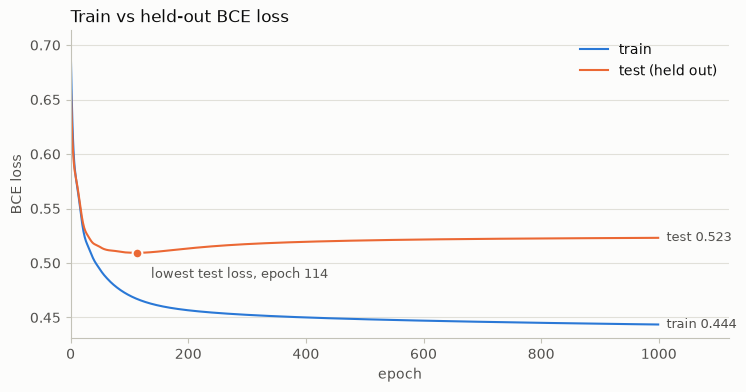

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(train_losses, color=TERMINATED, label="train")
ax.plot(test_losses, color=FAILED, label="test (held out)")
best = int(np.argmin(test_losses))
ax.plot(best, test_losses[best], "o", color=FAILED, markersize=7, markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.annotate(f"lowest test loss, epoch {best + 1}", (best, test_losses[best]), xytext=(10, -18),
            textcoords="offset points", color=INK_2, fontsize=9)
for series, name in ((train_losses, "train"), (test_losses, "test")):
    ax.annotate(f"{name} {series[-1]:.3f}", (len(series) - 1, series[-1]), xytext=(6, 0),
                textcoords="offset points", va="center", color=INK_2, fontsize=9)
ax.set_xlim(0, num_epochs * 1.12)
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.grid(axis="y")
ax.legend(loc="upper right")
ax.set_title("Train vs held-out BCE loss", loc="left")
plt.show()

**Reading the loss curves.** Training converges: the train loss falls smoothly from 0.69 to 0.444 and is still creeping down at epoch 1,000.

The held-out loss tells a second story. It bottoms out at about 0.509 around epoch 114, then drifts up to 0.523 while the train loss keeps falling. After roughly the first hundred epochs, the model starts memorizing the 1,848 training tasks instead of learning patterns that transfer.

The drift looks small (+0.014 BCE), but section 7 shows where it ends up: in the shapes of the curves.

## 6. Evaluate on held-out tasks

We report accuracy at a 0.5 threshold and ROC-AUC, which doesn't depend on the threshold, plus the confusion matrix. With a 28% failure rate, accuracy only means something next to the **majority-class baseline**: always predicting "Terminated" already scores 72%.

In [9]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_t).numpy()
    test_preds = model(X_test_t).numpy()

train_acc = accuracy_score(y_train, train_preds > 0.5)
test_acc = accuracy_score(y_test, test_preds > 0.5)
train_auc = roc_auc_score(y_train, train_preds)
test_auc = roc_auc_score(y_test, test_preds)

print(f"Train accuracy: {train_acc:.4f}   Train AUC: {train_auc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}   Test  AUC: {test_auc:.4f}")
print(f"Majority-class baseline accuracy (always predict Terminated): {1 - y_test.mean():.4f}")

cm = confusion_matrix(y_test, test_preds > 0.5)
print("\nConfusion matrix (test set, threshold 0.5):")
print(pd.DataFrame(cm, index=["actual Terminated", "actual Failed"],
                   columns=["pred Terminated", "pred Failed"]).to_string())
tn, fp, fn, tp = cm.ravel()
print(f"\nFailures caught (recall):            {tp}/{tp + fn} = {tp / (tp + fn):.1%}")
print(f"Flagged tasks that failed (precision): {tp}/{tp + fp} = {tp / max(tp + fp, 1):.1%}")

Train accuracy: 0.8149   Train AUC: 0.8105
Test  accuracy: 0.7814   Test  AUC: 0.7187
Majority-class baseline accuracy (always predict Terminated): 0.7208

Confusion matrix (test set, threshold 0.5):
                   pred Terminated  pred Failed
actual Terminated              310           23
actual Failed                   78           51

Failures caught (recall):            51/129 = 39.5%
Flagged tasks that failed (precision): 51/74 = 68.9%


**Reading the metrics.**
- **Test AUC is 0.719.** Given a random failed task and a random successful one, the model gives the failed one the higher risk score 72% of the time. That is real signal, but modest.
- **Accuracy is 78.1% against a 72.1% majority baseline**, so the model beats always-guess-success by about 6 points.
- **Train AUC is 0.811 vs test 0.719.** That 0.09 gap is the same overfitting the loss curves showed.
- **At the default 0.5 threshold, the model is conservative.** It catches 51 of the 129 held-out failures (39.5% recall), and when it flags a task, it is right 69% of the time (precision). For an alerting use case you would lower the threshold to trade precision for recall; AUC summarizes that whole trade-off in one number.

## 7. The payoff: ten curves, each readable on its own

`model.plot_all_curves()` draws each learned $\varphi_i$.

- **The y-axis is that feature's contribution to the log-odds of failure.** Above the zero line the feature pushes a task toward failure; below it, toward success. Log-odds add up: a feature at +0.5 multiplies the failure odds by $e^{0.5} \approx 1.65$, with everything else held fixed.
- **Read shape and slope, not absolute height.** A constant can move freely between a curve and the model's bias term, so a curve's vertical offset carries no meaning on its own. Its *changes* do.
- **The x-axis is relabelled in raw trace units** by inverting the per-feature scaling. The tick marks along the bottom show where the training tasks actually sit. A curve is only trustworthy where it has data under it: between the few request sizes that dominate `plan_cpu` or `plan_mem`, it is interpolating.

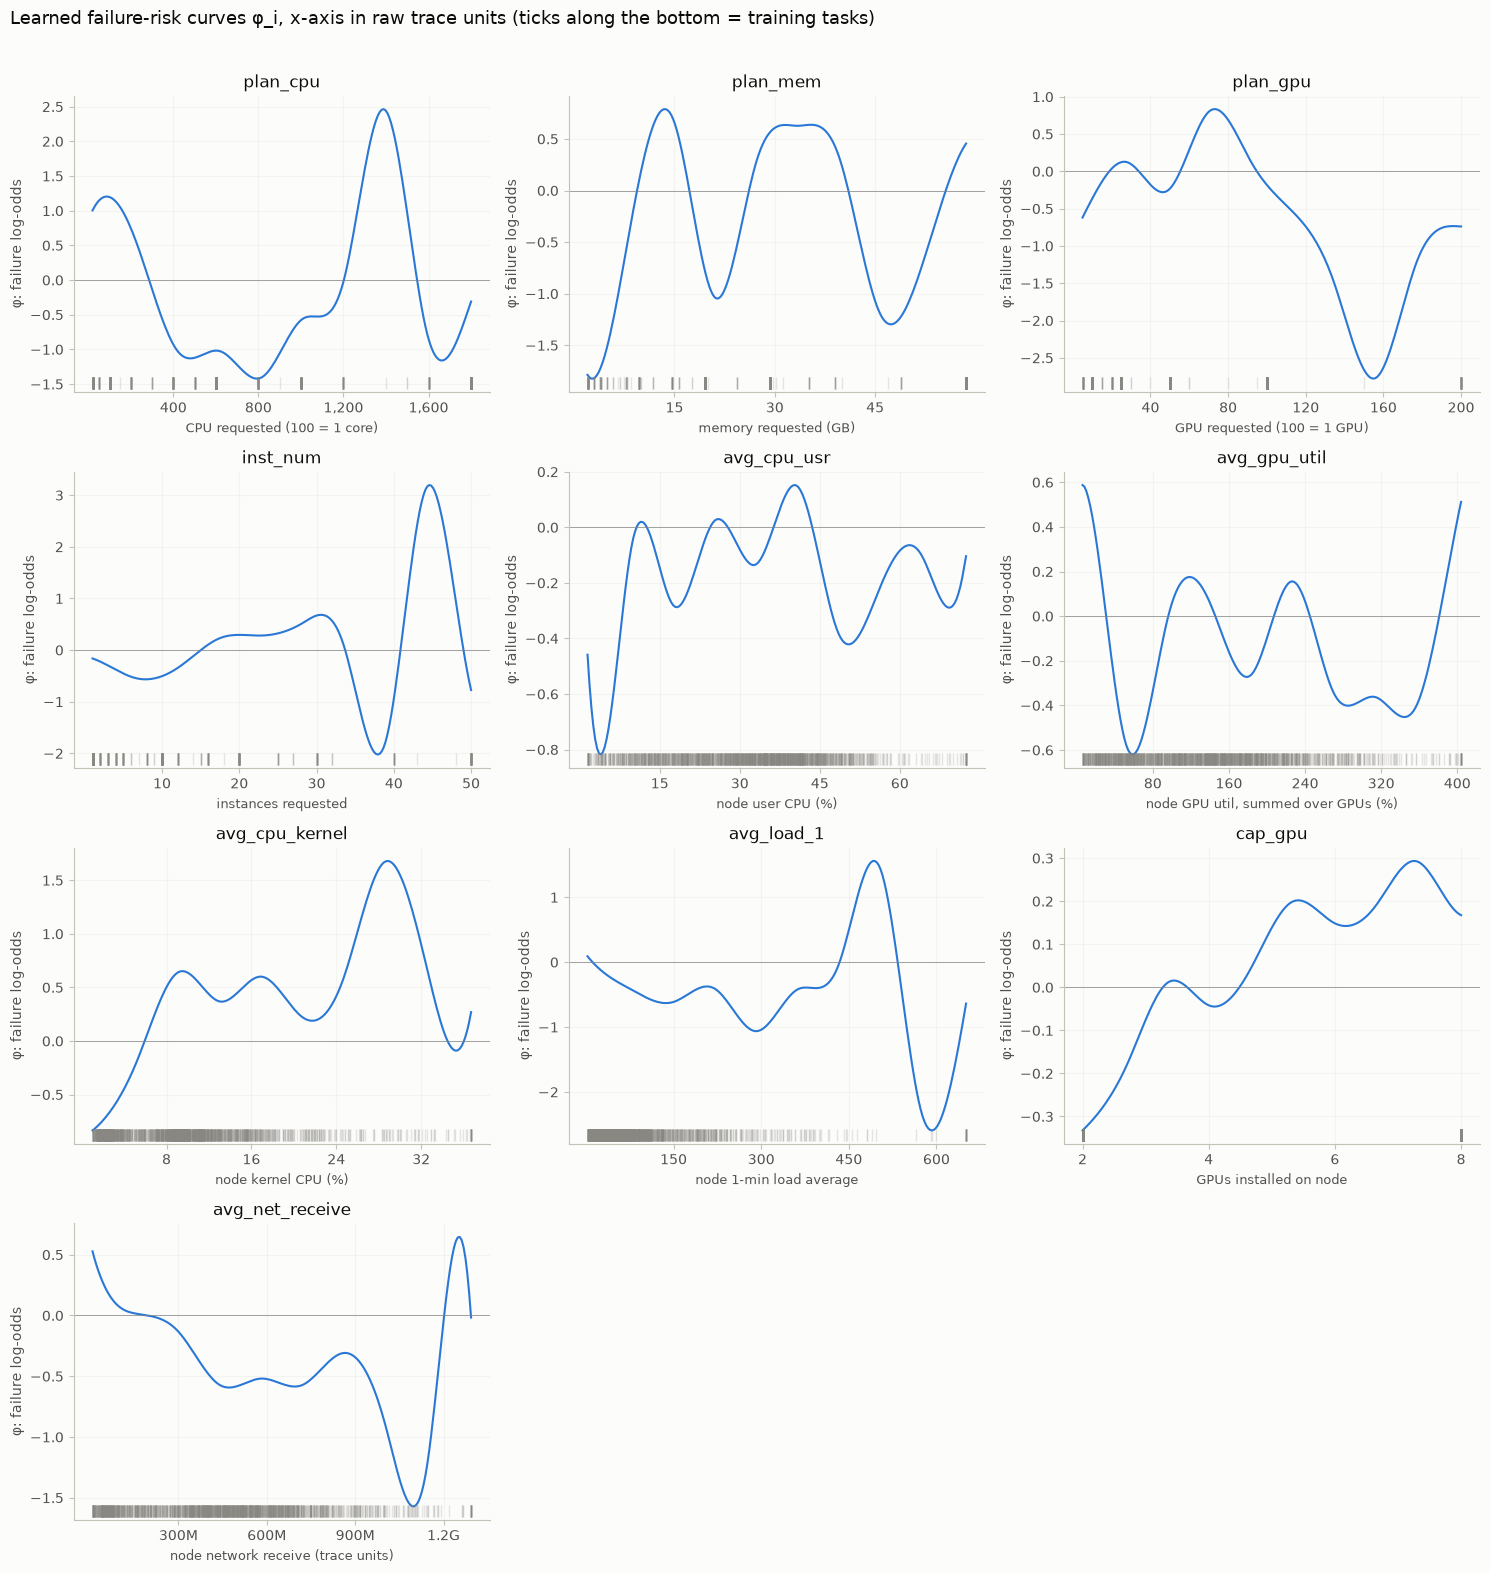

In [10]:
fig = model.plot_all_curves()

for ax, name in zip(fig.axes, FEATURE_NAMES):
    lo, hi = feature_ranges[name]
    raw_ticks = MaxNLocator(nbins=5, integer=True).tick_values(lo, hi)
    raw_ticks = raw_ticks[(raw_ticks >= lo) & (raw_ticks <= hi)]
    ax.set_xticks((raw_ticks - lo) / (hi - lo))
    ax.set_xticklabels([compact(t) for t in raw_ticks])
    ax.set_xlabel(FEATURE_UNITS[name], fontsize=9)
    ax.set_ylabel("φ: failure log-odds")
    ax.plot(X_train_s[name], np.full(len(X_train_s), 0.03), "|", color=MUTED, alpha=0.2, markersize=9,
            transform=ax.get_xaxis_transform())

fig.suptitle("Learned failure-risk curves φ_i, x-axis in raw trace units (ticks along the bottom = training tasks)",
             x=0.01, ha="left", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

**Reading the curves: start with the rug, then the curve.**

**Where the curves are trustworthy (dense rug):**
- `avg_cpu_kernel`: failure risk climbs from about -0.8 at ~1% kernel CPU to about +0.6 at 8-10%, and stays between about +0.2 and +0.6 through ~22%. Tasks that land on a node whose kernel CPU was near idle in the prior hour fail less often. This matches the histogram, where failures pile up around 8-12%.
- `avg_net_receive`: highest near zero receive (about +0.5), falling to about -0.5 across the dense 400M-700M range. Nodes that were moving a lot of network data before the task arrived are associated with *lower* risk.
- `avg_load_1`: a gentle decline from about 0 on idle nodes to about -0.6 by a load average of 150. Busier run queues go with slightly lower risk, not higher.
- `avg_cpu_usr` and `avg_gpu_util` oscillate (roughly -0.6 to +0.6) across their dense ranges with no consistent direction. On their own they add little, and the oscillation itself is a sign of fitting noise.

The last three readings look backwards to an SRE ("a busier node means safer tasks?"). A likely explanation is that recent node activity is a fingerprint of the node's *pool*: its hardware class and the workloads scheduled there. The same overlap explains the next curve.

**Discrete features: read the curve only at the rug positions.**
- `cap_gpu` has data at exactly 2 and 8 GPUs, so the meaningful number is φ(8) − φ(2), about +0.5 log-odds or 1.65x the failure odds on 8-GPU nodes. That is well below the raw gap (35% vs 12% failure is +1.37 log-odds). The additive model *shares* the node-pool effect between `cap_gpu` and the telemetry features correlated with it: each curve is an effect *given the other nine features*, not a raw comparison.
- `plan_cpu`: small CPU requests (under ~2 cores) sit around +1, the dominant 6-core request around -1, and 18 cores around -0.3. In the histogram, the ~1-core bar is mostly orange.
- `plan_mem` and `plan_gpu` each take a handful of values. Compare their curves only at those values (for example 29.3 GB vs 2 GB, or 25 vs 100), and weigh each by how many tasks sit there.

**Where the curves are artifacts (sparse or empty rug).** These are the large swings:
- `plan_cpu`'s +2.5 peak near 1,400
- `plan_gpu`'s -2.7 dip near 150
- `inst_num`'s +3 spike near 44 and -2 dip near 38
- `avg_load_1`'s +1.5 / -2.6 swing above 450
- `avg_net_receive`'s dip and spike above 1G

Every one of them sits over a stretch with at most a handful of training tasks. Each B-spline coefficient there is fitted to a few points, and nothing in the loss asks the curve to stay smooth between them. **These are overfitting artifacts, not findings**, and they are the most important caveat in this notebook. An SRE reading `plan_cpu` must not conclude that 14-core requests are dangerous.

## 8. What this does and doesn't show

- **This is a 5,000-task sample, 2,310 of which survive the pipeline.** The curves are estimated from about 1,850 training tasks, and features with few distinct values (`cap_gpu`, `inst_num`) have only a handful of points along their axis. Rerunning `build_kanvas_dataset()` with a larger `sample_n_tasks` scales linearly. Reading the raw tables costs about a minute whatever the sample size.
- **Scope:** GPU tasks whose node had other-job activity in the prior hour, with a 28% base failure rate versus 22.5% trace-wide.
- **Telemetry is a proxy.** Each `pai_machine_metric` row is one worker's lifetime average, so the one-hour lookback describes the node's recent state, not a real-time reading at the moment of scheduling.
- **Associations, not causes.** For example, 8-GPU nodes host different workloads than 2-GPU nodes, so `cap_gpu` may be standing in for job type. An additive model makes each association easy to *see*, but it doesn't turn correlation into causation.
- **The biggest caveat is the curve artifacts from section 7.** Large swings over sparse data come from unpenalized spline coefficients, and they are the first thing to fix before these curves are shown to anyone making operational decisions.
- **Next:**
  - a smoothness penalty on neighbouring spline coefficients, with early stopping chosen on a validation split; both target those artifacts
  - the full-trace run
  - error bars on each curve, for example by retraining on bootstrap resamples